## About the Dataset

This dataset contains satellite-detected wildfire hotspots, enriched with daily weather data, across seven fire-prone regions worldwide. It is designed for machine learning research focused on wildfire risk prediction, intensity classification, and seasonal pattern analysis.

### Coverage

- **Regions:** South Asia, Southeast Asia, Mediterranean, Sub-Saharan Africa, South America, North America, Australia  
- **Date Range:** January 2024 – December 2025  
- **Events:** 15,500 fire detection events across 35 countries  

### Features

- **latitude, longitude:** Geographic coordinates of the fire event  
- **acq_date:** Date of fire detection  
- **acq_time:** Time of fire detection (HHMM format)  
- **year, month:** Year and month of detection  
- **season:** Season of the year (e.g., summer, winter)  
- **daynight:** Indicates if the fire was detected during the day or night  
- **region:** Geographic region of the fire event  
- **country:** Country where the fire occurred  
- **fire_type:** Type of fire event (Wildfire, Agriculture, Peatland, Savanna)  
- **satellite:** Satellite used for detection (NOAA-20, Suomi-NPP)  
- **instrument:** Sensor/instrument used (VIIRS, MODIS)  
- **brightness_k:** Brightness temperature in Kelvin (related to fire activity)  
- **confidence:** Detection confidence level (high, nominal, low)  
- **temp_max_c:** Maximum air temperature on detection day (°C)  
- **wind_max_kmh:** Maximum wind speed (km/h), important for fire spread  
- **precip_mm:** Precipitation (proxy for fire suppression)  
- **humidity_pct:** Relative humidity (%)  

### Target Variable

- **fire_intensity:** Intensity level of the wildfire (categorical, 4 classes):  
    - 0 = Low  
    - 1 = Moderate  
    - 2 = High  
    - 3 = Extreme

In [87]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [88]:
# Load the dataset
df = pd.read_csv('../data/raw/wildfire_cls_train_full.csv')

In [89]:
# Lets check the first few rows of the dataset
df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate


In [90]:
# Last few rows of the dataset
df.tail()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
4335,31.1836,2.4033,2024-06-19,558,2024,6.0,Summer,N,Mediterranean,Portugal,Forest,AQUA,MODIS,NaN,high,38.4,33.7,2.72,7.0,High
4336,8.6168,63.6064,2025-04-17,908,2025,4.0,Spring,D,South_Asia,Sri Lanka,Grassland,TERRA,MODIS,349.95,high,25.3,11.8,1.20,36.3,Moderate
4337,42.4516,1.1680,2024-09-13,237,2024,9.0,Autumn,N,Mediterranean,Spain,Wildfire,TERRA,MODIS,315.38,nominal,42.9,60.0,0.20,24.7,Moderate
4338,17.3111,89.6311,2024-12-05,56,2024,12.0,Winter,N,South_Asia,Pakistan,Forest,TERRA,MODIS,334.41,high,37.8,25.9,5.70,41.7,High
4339,15.2528,91.7403,2025-05-09,315,2025,5.0,Spring,N,South_Asia,Sri Lanka,Forest,TERRA,MODIS,335.51,nominal,28.8,5.1,2.04,34.8,Moderate


In [91]:
df.shape
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 4340
Number of columns: 20


In [92]:
# Lets have data overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        4340 non-null   float64
 1   longitude       4340 non-null   float64
 2   acq_date        4340 non-null   str    
 3   acq_time        4340 non-null   int64  
 4   year            4340 non-null   int64  
 5   month           3924 non-null   float64
 6   season          4340 non-null   str    
 7   daynight        4340 non-null   str    
 8   region          4340 non-null   str    
 9   country         4340 non-null   str    
 10  fire_type       4340 non-null   str    
 11  satellite       4340 non-null   str    
 12  instrument      4340 non-null   str    
 13  brightness_k    4013 non-null   float64
 14  confidence      4340 non-null   str    
 15  temp_max_c      4340 non-null   float64
 16  wind_max_kmh    4133 non-null   float64
 17  precip_mm       4340 non-null   float64
 18 

In [93]:
df.describe()

,latitude,longitude,acq_time,year,month,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,4340.000000,4340.000000,4340.000000,4340.000000,3924.000000,4013.000000,4340.000000,4133.000000,4340.000000,4340.000000
mean,9.821703,29.430626,1177.046774,2024.501843,7.240316,336.677742,35.082627,17.508033,2.597111,37.924378
std,24.321271,78.842700,683.844117,0.500054,2.791615,18.539217,5.821218,17.051980,3.062512,18.731153
min,-42.988300,-167.990600,0.000000,2024.000000,1.000000,290.000000,17.700000,0.000000,0.000000,5.000000
25%,-8.611625,-40.980600,602.000000,2024.000000,5.000000,324.860000,31.000000,5.100000,0.600000,24.200000
50%,10.268500,34.833700,1208.000000,2025.000000,8.000000,335.530000,35.100000,12.400000,1.540000,36.200000
75%,29.011025,95.166775,1752.000000,2025.000000,9.000000,346.990000,39.125000,24.000000,3.370000,50.500000
max,69.930900,153.754900,2359.000000,2025.000000,12.000000,503.710000,54.100000,130.700000,23.690000,95.000000


In [94]:
# Lets check missing values
df.isnull().sum()

latitude            0
longitude           0
acq_date            0
acq_time            0
year                0
month             416
season              0
daynight            0
region              0
country             0
fire_type           0
satellite           0
instrument          0
brightness_k      327
confidence          0
temp_max_c          0
wind_max_kmh      207
precip_mm           0
humidity_pct        0
fire_intensity      0
dtype: int64

In [95]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_pct
})

missing_table[missing_table["Missing Values"] > 0]

,Missing Values,Percentage
month,416,9.585253
brightness_k,327,7.534562
wind_max_kmh,207,4.769585


In [96]:
# check duplicates values
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


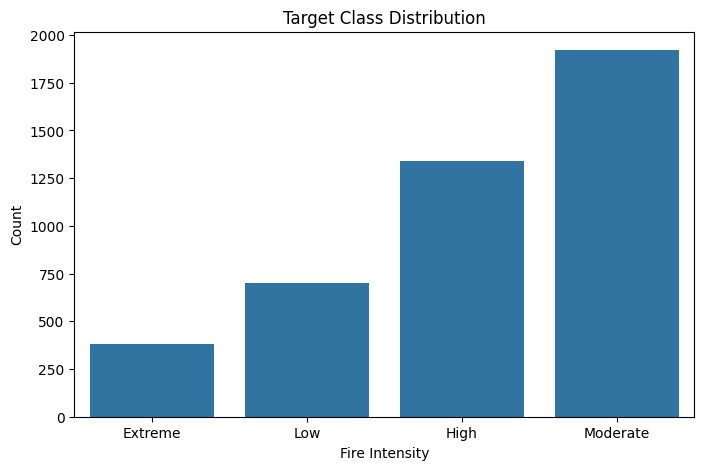

In [97]:
# Target Variable  Analysis
plt.figure(figsize=(8,5))
sns.countplot(x='fire_intensity', data=df)
plt.title("Target Class Distribution")
plt.xlabel("Fire Intensity")
plt.ylabel("Count")
plt.show()

In [98]:
df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate


In [99]:
# Lets see the numerical features 
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical Features:", numerical_features)

Numerical Features: ['latitude', 'longitude', 'acq_time', 'year', 'month', 'brightness_k', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct']


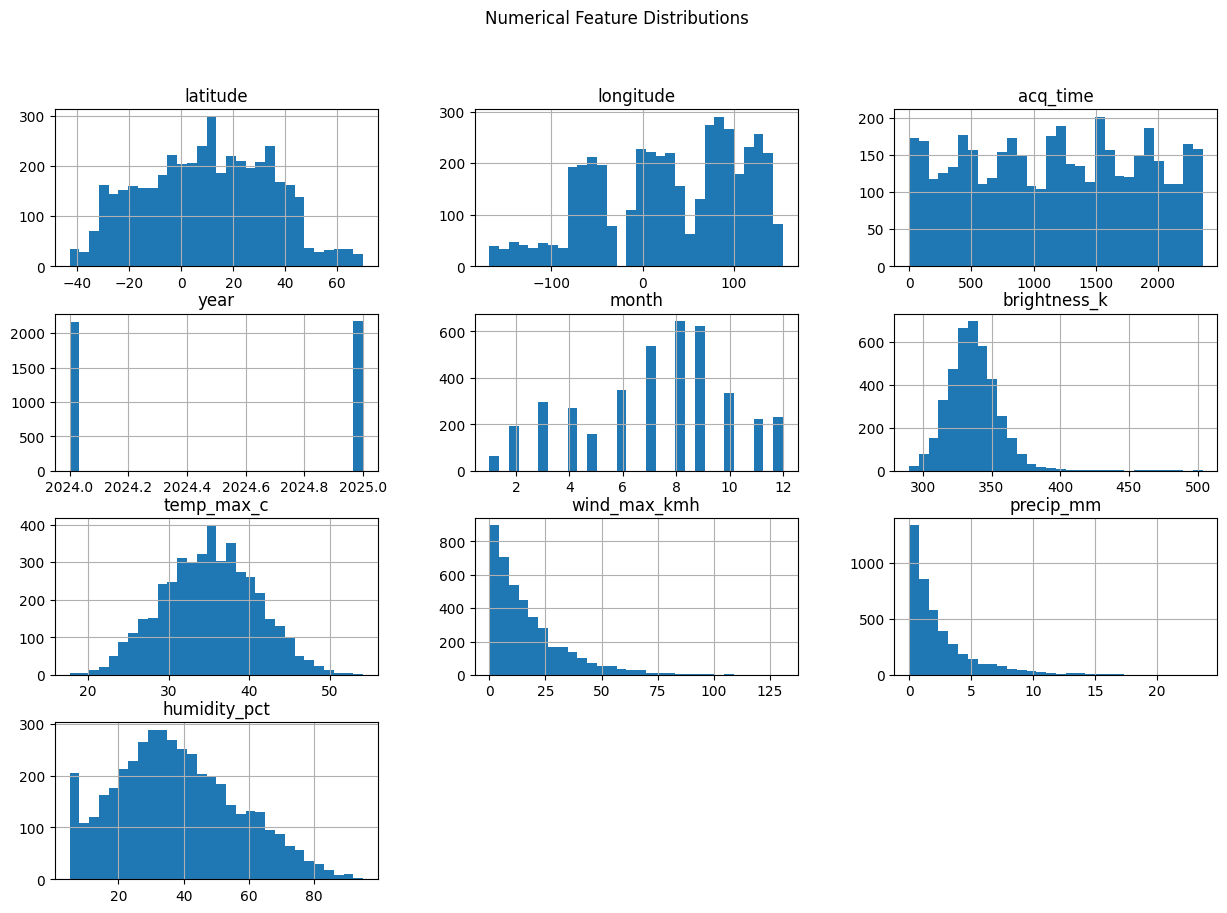

In [100]:
# Plot histograms for numerical features
df[numerical_features].hist(figsize=(15,10), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.show()

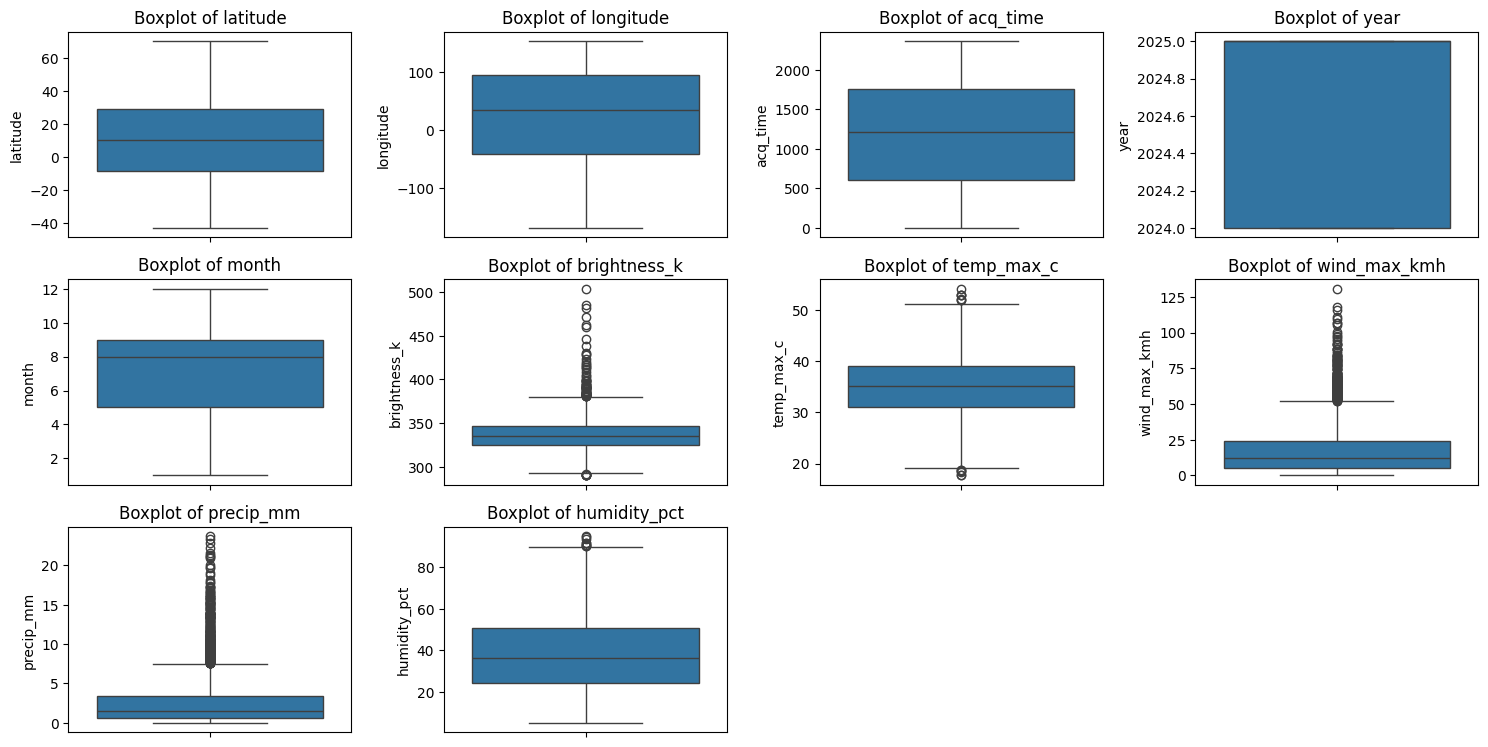

In [101]:
# Check the outliers using some method like boxplot or z-score method or IQR methods , here i will first visualize the outliers using boxplot and then i will use IQR method to remove the outliers and then visualize the boxplot again to see the effect of outliers removal.
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_features):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [102]:
# Lets count the total number of outliers in each numerical feature using IQR method
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers)

outlier_summary = {}

for col in numerical_features:
    outlier_summary[col] = detect_outliers(df, col)

outlier_summary = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
outlier_summary.sort_values(by='Outlier Count', ascending=False)

,Outlier Count
precip_mm,312
wind_max_kmh,212
brightness_k,71
temp_max_c,13
humidity_pct,9
latitude,0
longitude,0
month,0
acq_time,0
year,0


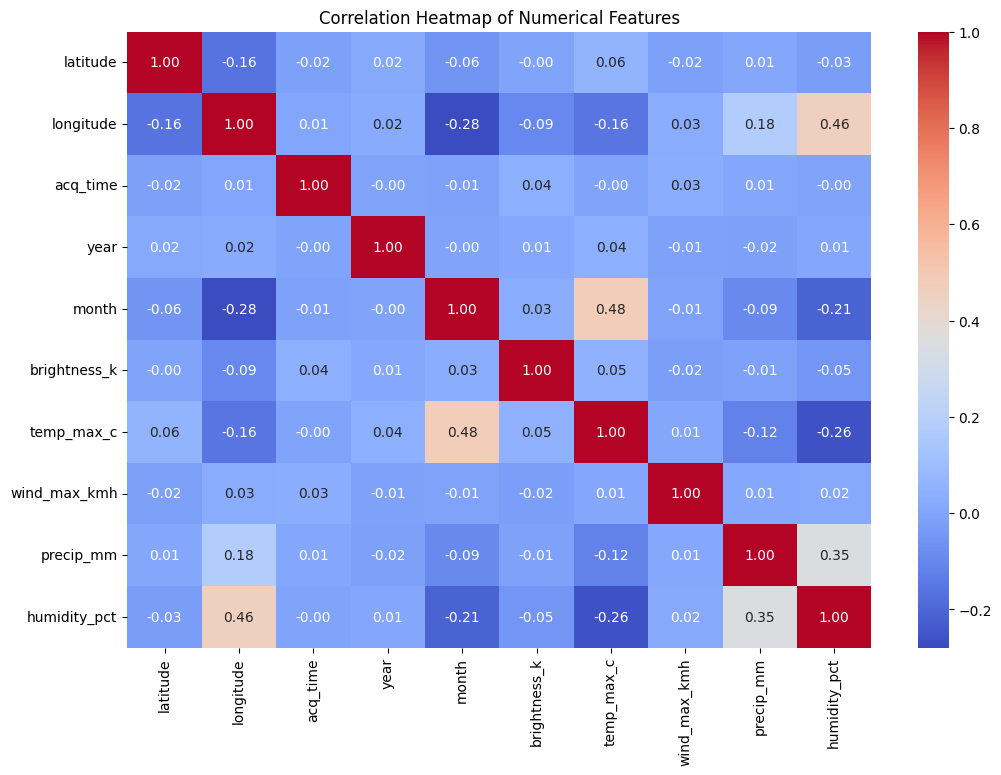

In [103]:
# lets see the correlation between the numerical features
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


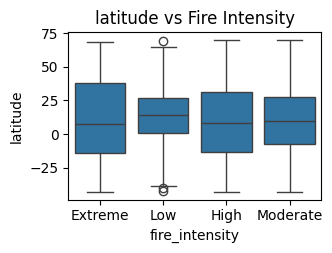

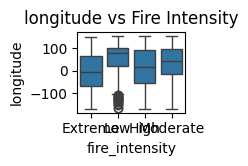

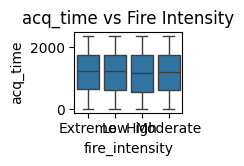

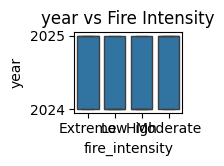

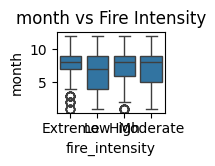

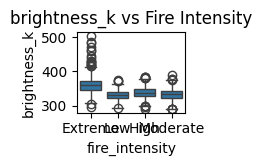

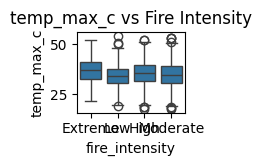

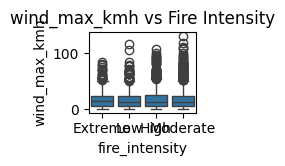

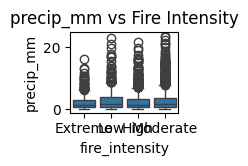

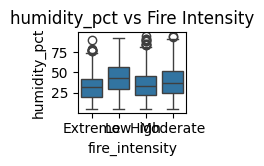

In [104]:
# feature vs target variable analysis
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_features):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x='fire_intensity', y=col, data=df)
    plt.title(f"{col} vs Fire Intensity")
    plt.show()

In [105]:
# categorical features analysis
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", categorical_features)


Categorical Features: ['acq_date', 'season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'confidence', 'fire_intensity']


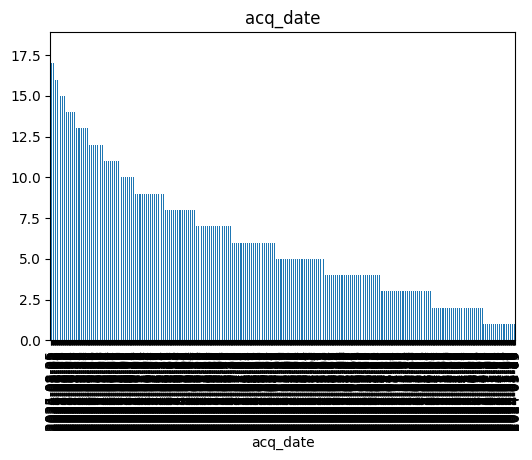

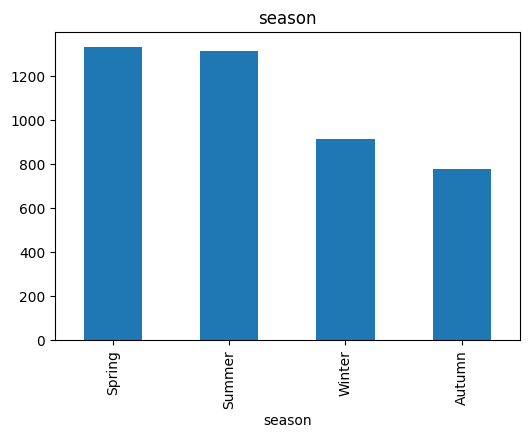

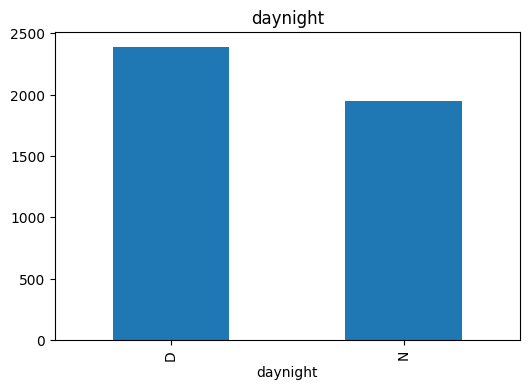

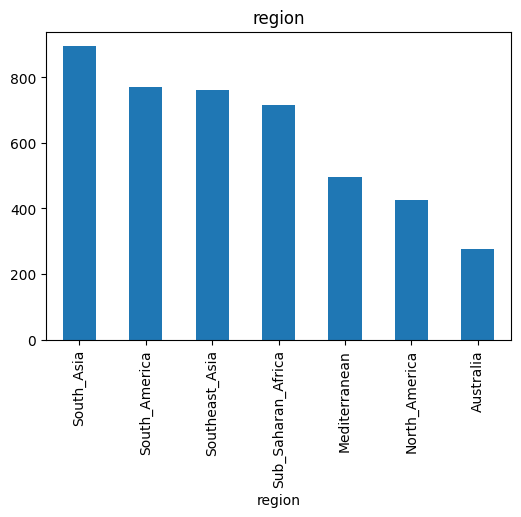

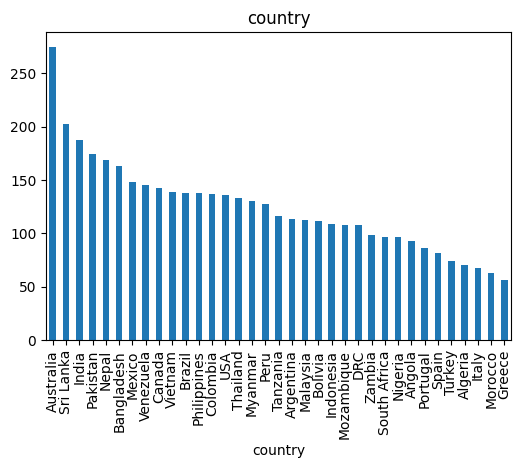

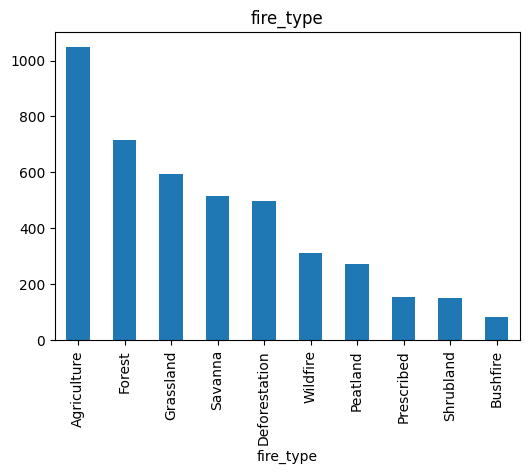

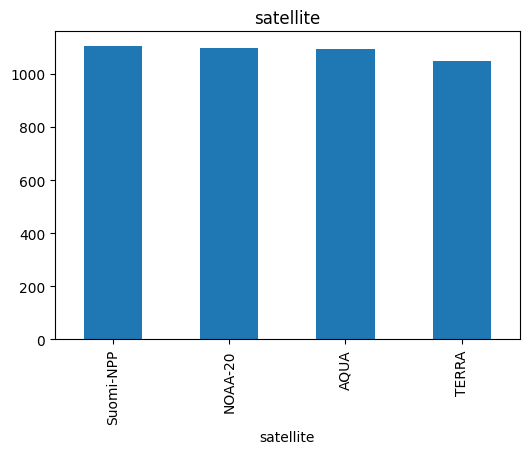

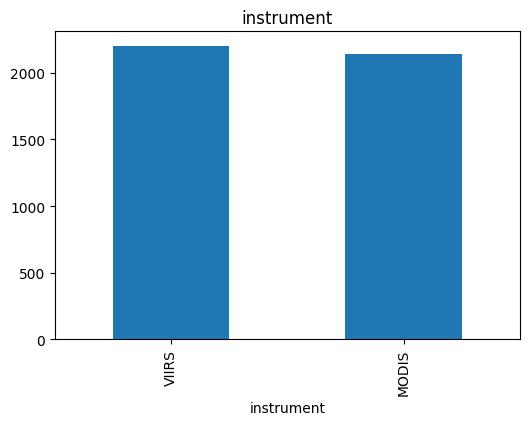

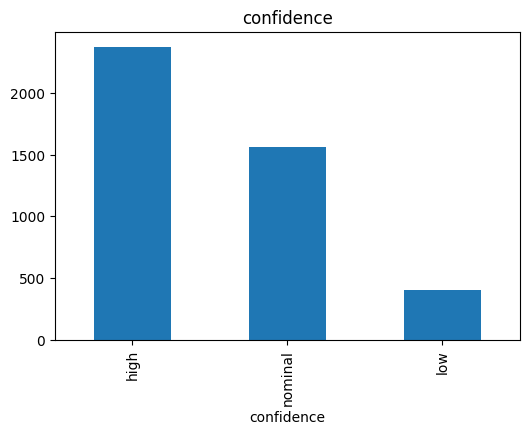

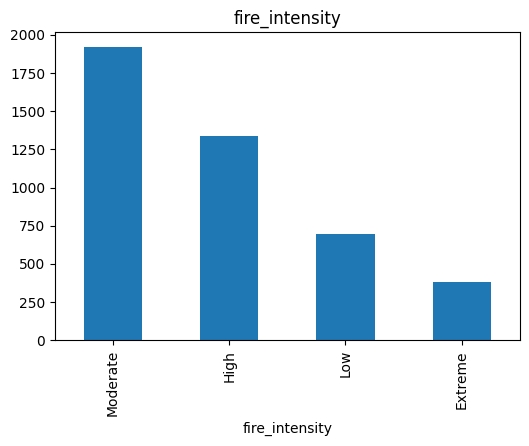

In [106]:
for col in categorical_features:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

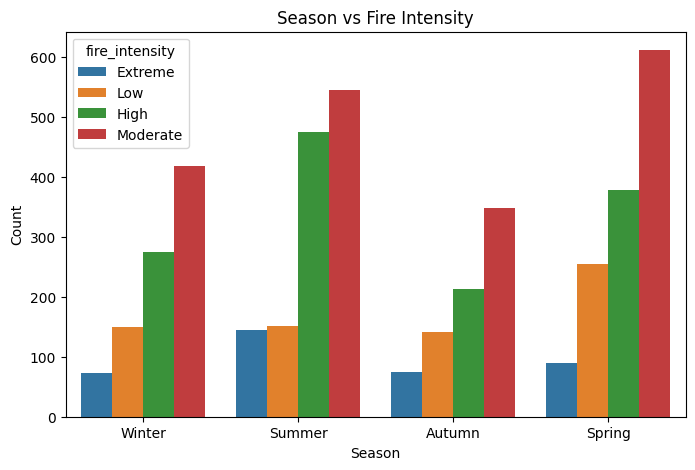

In [107]:
# Seasonal vs Fire Intensity analysis
plt.figure(figsize=(8,5))
sns.countplot(x='season', hue='fire_intensity', data=df)
plt.title("Season vs Fire Intensity")
plt.xlabel("Season")
plt.ylabel("Count")
plt.show()


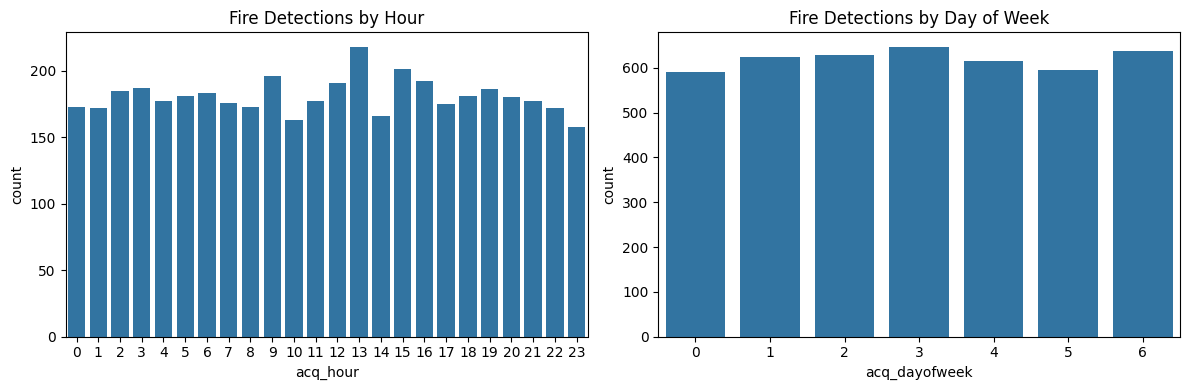

In [108]:
# lets see the temporal trends of fire events over time (monthly/yearly trends)
df['acq_datetime'] = pd.to_datetime(df['acq_date'] + ' ' + df['acq_time'].astype(str).str.zfill(4), format='%Y-%m-%d %H%M')
df['acq_hour'] = df['acq_datetime'].dt.hour
df['acq_dayofweek'] = df['acq_datetime'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='acq_hour', data=df, ax=axes[0])
axes[0].set_title('Fire Detections by Hour')
sns.countplot(x='acq_dayofweek', data=df, ax=axes[1])
axes[1].set_title('Fire Detections by Day of Week')
plt.tight_layout()
plt.show()

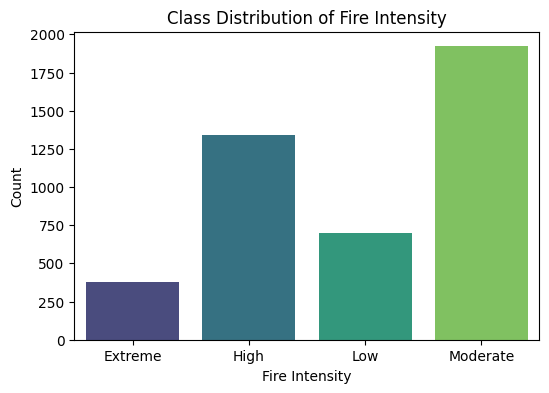

Class Distribution (Percent):
fire_intensity
Extreme      8.78
High        30.88
Low         16.08
Moderate    44.26
Name: count, dtype: float64


In [109]:
# visualize the class imbalance in the target variable
class_counts = df['fire_intensity'].value_counts().sort_index()
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution of Fire Intensity')
plt.xlabel('Fire Intensity')
plt.ylabel('Count')
plt.show()
print('Class Distribution (Percent):')
print((class_counts / class_counts.sum() * 100).round(2))

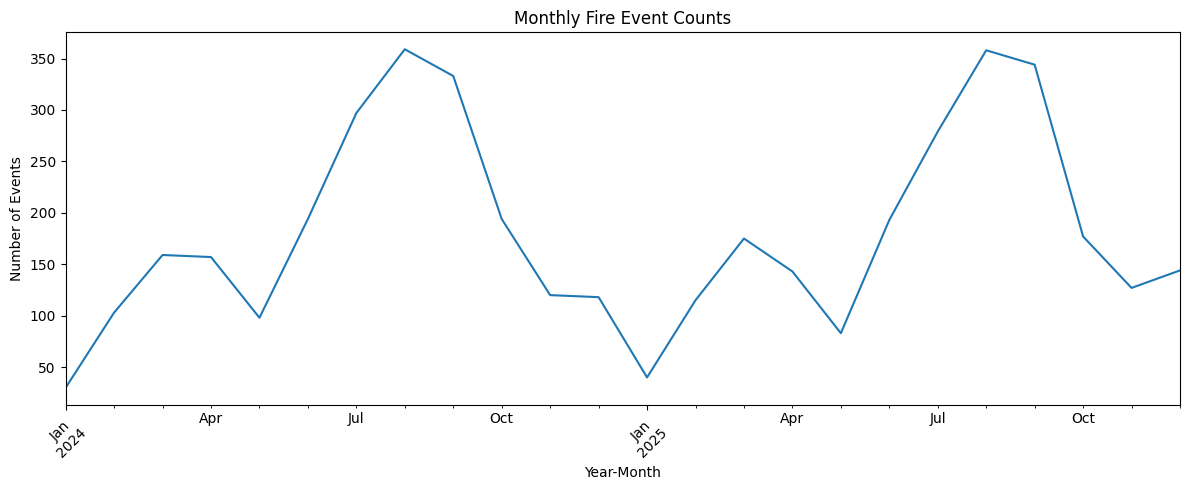

In [110]:
# lets see the temporal trends of fire events over time (monthly/yearly trends)
df['year_month'] = df['acq_datetime'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size()
plt.figure(figsize=(12,5))
monthly_counts.plot()
plt.title('Monthly Fire Event Counts')
plt.xlabel('Year-Month')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

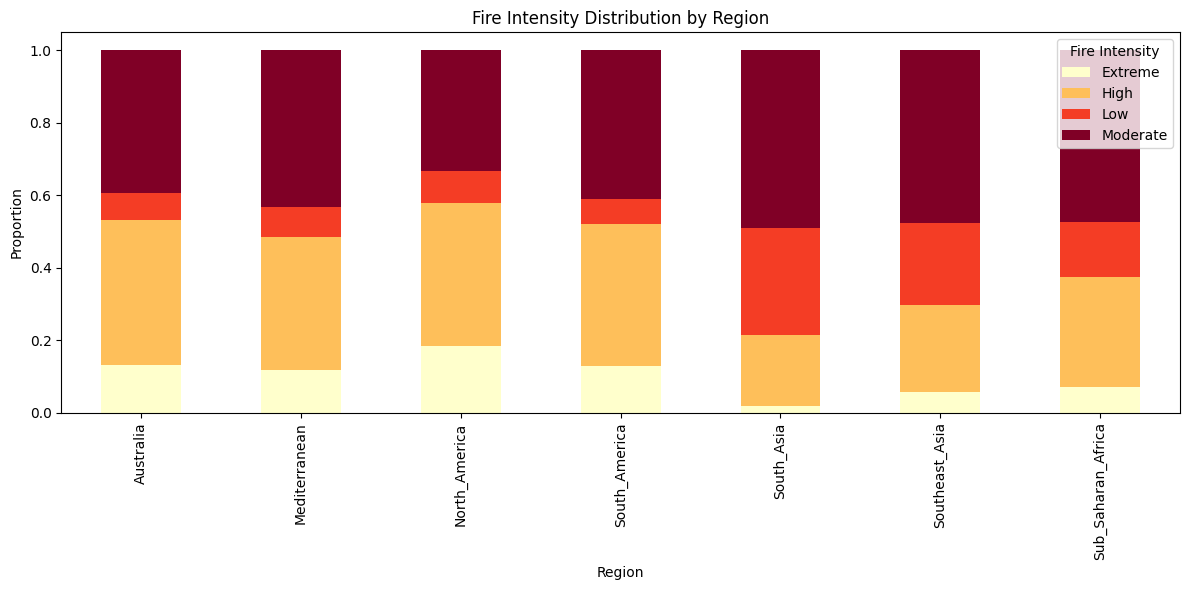

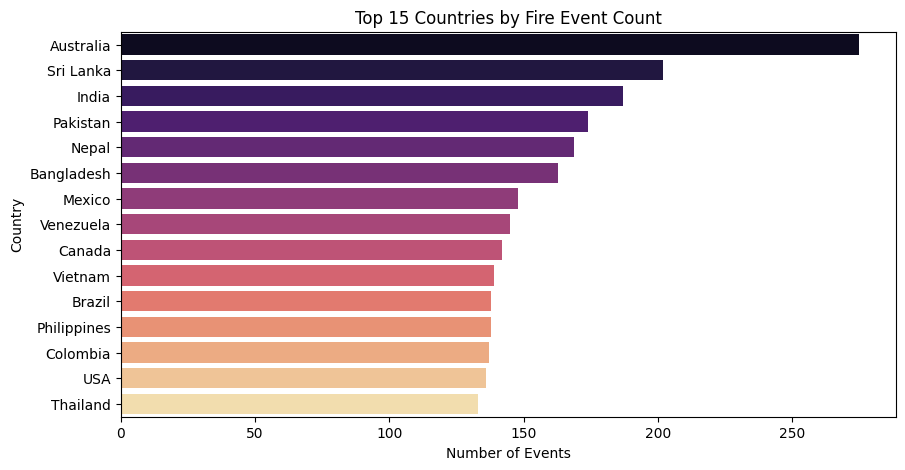

In [111]:
# Region/Country Level Analysis 
region_counts = df.groupby('region')['fire_intensity'].value_counts(normalize=True).unstack().fillna(0)
region_counts.plot(kind='bar', stacked=True, figsize=(12,6), colormap='YlOrRd')
plt.title('Fire Intensity Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Proportion')
plt.legend(title='Fire Intensity')
plt.tight_layout()
plt.show()

country_counts = df['country'].value_counts().head(15)
plt.figure(figsize=(10,5))
sns.barplot(y=country_counts.index, x=country_counts.values, palette='magma')
plt.title('Top 15 Countries by Fire Event Count')
plt.xlabel('Number of Events')
plt.ylabel('Country')
plt.show()